# Outliers univariantes (Z-score, IQR, boxplots)

**Índice**
1. Outliers del importe: boxplots, Z-score e IQR
2. Outliers en otras variables

## Conexión y carga

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect

AZUL = "#2b6cb0"
AZULES = "Blues_r"
CLASES = {"normal": "#9ecae1", "fraude": "#08306b"}
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

client = clickhouse_connect.get_client(host="localhost", port=8123, username="default",
                                       password="password", database="fraude_pagos")

df = client.query_df("SELECT * FROM features_transaccion")
df["clase"] = df["es_fraude"].map({1: "fraude", 0: "normal"})
TOTAL_FRAUDE = int(df["es_fraude"].sum())
print(f"{len(df):,} transacciones, {TOTAL_FRAUDE} fraudulentas ({df['es_fraude'].mean() * 100:.2f} %)")

def evaluar(marcadas, nombre):
    n = int(marcadas.sum())
    vp = int((marcadas & (df["es_fraude"] == 1)).sum())
    return {"método": nombre, "marcadas": n, "% del total": n / len(df) * 100,
            "fraude detectado": vp, "precisión %": vp / n * 100 if n else 0,
            "recall %": vp / TOTAL_FRAUDE * 100}

39,603 transacciones, 697 fraudulentas (1.76 %)


## 1. Outliers univariantes del importe

### 1.1 Boxplots

Un boxplot marca como outliers los puntos fuera de los bigotes. A la izquierda, la cantidad tal cual. A la derecha, en escala logarítmica. Como el importe es muy asimétrico, en escala lineal casi todo queda aplastado abajo y cientos de transacciones normales salen como outliers.

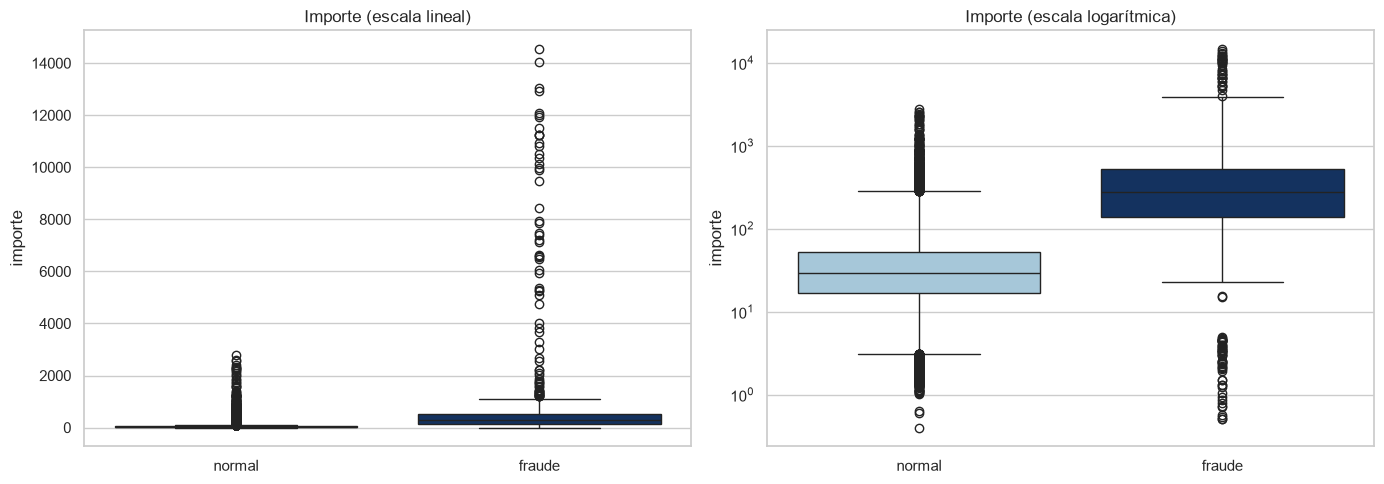

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="clase", y="importe", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[0])
axes[0].set_title("Importe (escala lineal)")
axes[0].set_xlabel("")
sns.boxplot(data=df, x="clase", y="importe", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, log_scale=True, ax=axes[1])
axes[1].set_title("Importe (escala logarítmica)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

### 1.2 Z-score e IQR

- Z-score global: |z| > 3, con z = (importe − media) / desviación. Asume una distribución normal.
- Z-score global sobre log(importe): lo mismo, pero sobre el logaritmo, que es mucho más simétrico.
- IQR global: fuera de [Q1 − 1,5·IQR, Q3 + 1,5·IQR]. No asume normalidad.
- IQR global sobre log(importe).
- Z-score por cliente (z_importe_cliente > 3): compara el importe con el historial de ese cliente, usando solo sus compras anteriores.

Precisión: de las transacciones marcadas, qué % es fraude. 
Recall: del fraude total, qué % se marca.

In [4]:
def z_score(x):
    return (x - x.mean()) / x.std()

def fuera_iqr(x, k=1.5):
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (x < q1 - k * iqr) | (x > q3 + k * iqr)

metodos = {
    "Z-score global": z_score(df["importe"]).abs() > 3,
    "Z-score global (log)": z_score(df["log_importe"]).abs() > 3,
    "IQR global": fuera_iqr(df["importe"]),
    "IQR global (log)": fuera_iqr(df["log_importe"]),
    "Z-score por cliente": df["z_importe_cliente"] > 3,
}
comparativa = pd.DataFrame([evaluar(m, nombre) for nombre, m in metodos.items()])

q1, q3 = df["importe"].quantile([0.25, 0.75])
print(f"Media: {df['importe'].mean():.2f} €   Desviación: {df['importe'].std():.2f} €   "
      f"-> umbral Z-score: {df['importe'].mean() + 3 * df['importe'].std():.2f} €")
print(f"Q1: {q1:.2f} €   Q3: {q3:.2f} €   IQR: {q3 - q1:.2f} €   -> umbral IQR: {q3 + 1.5 * (q3 - q1):.2f} €\n")
comparativa.round(1)

Media: 60.06 €   Desviación: 307.20 €   -> umbral Z-score: 981.67 €
Q1: 17.07 €   Q3: 53.93 €   IQR: 36.86 €   -> umbral IQR: 109.22 €



,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,Z-score global,121,0.3,75,62.0,10.8
1,Z-score global (log),365,0.9,199,54.5,28.6
2,IQR global,3032,7.7,560,18.5,80.3
3,IQR global (log),872,2.2,354,40.6,50.8
4,Z-score por cliente,557,1.4,205,36.8,29.4


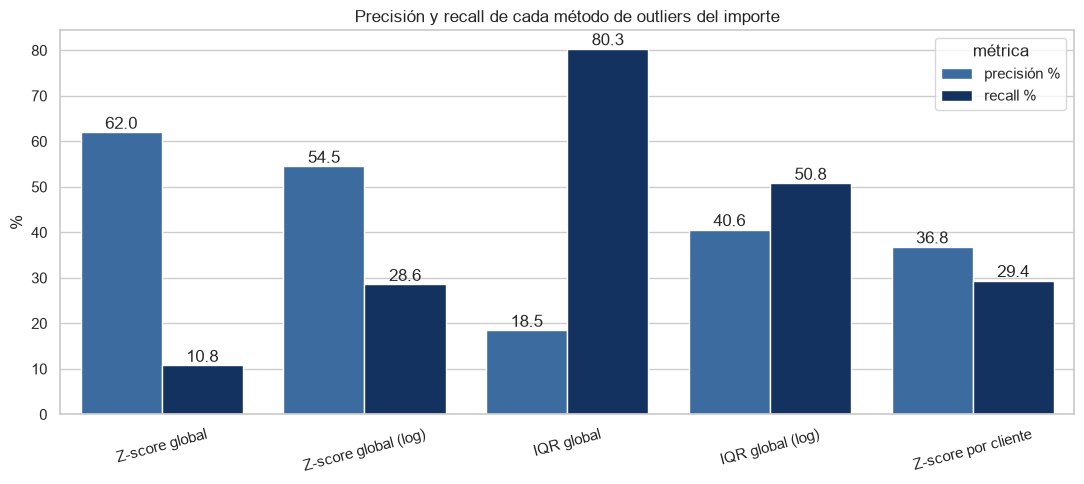

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
comp_larga = comparativa.melt(id_vars="método", value_vars=["precisión %", "recall %"],
                              var_name="métrica", value_name="valor")
sns.barplot(data=comp_larga, x="método", y="valor", hue="métrica",
            palette=[AZUL, "#08306b"], ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("Precisión y recall de cada método de outliers del importe")
ax.set_xlabel("")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

Z-score global: Tiene una precisión alta (65.5 %), pero un recall muy bajo (10.3 %), dejando escapar la gran mayoría del fraude.   

IQR global: Logra el mayor recall (73.8 %), pero su precisión cae drásticamente al 17.6 %, lo que genera demasiadas falsas alarmas.   

Balance: Los métodos basados en escala logarítmica (como el IQR global log con 41.9 % de precisión y 52.6 % de recall) ofrecen un equilibrio mucho más sensato para detectar fraudes de forma eficiente

### 1.3 ¿Qué tipos de fraude detecta cada método?

Porcentaje de las transacciones de cada tipo de fraude que marca cada método. Un método de outliers del importe solo puede detectar los fraudes con importes raros.

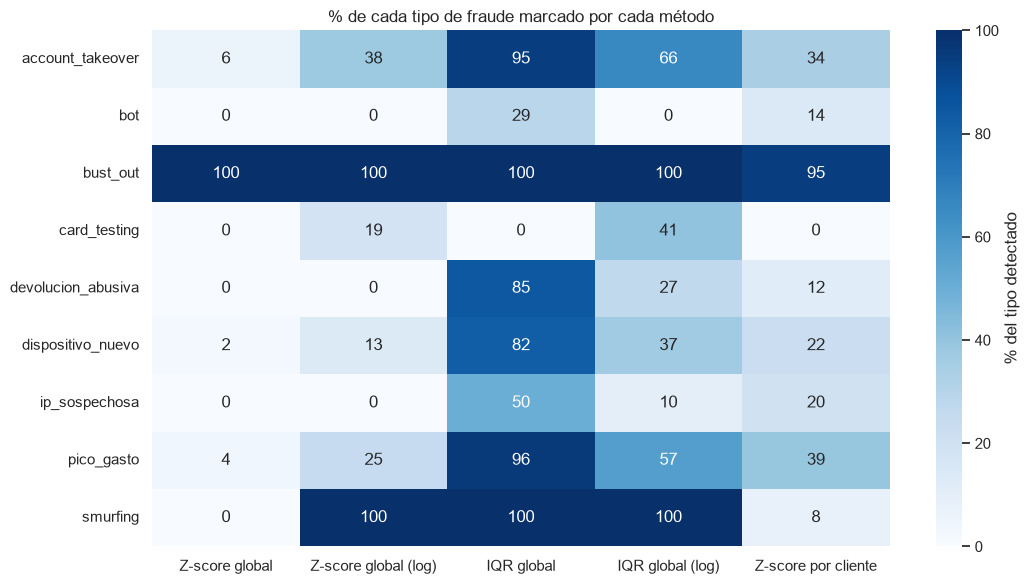

In [6]:
fraude = df[df["es_fraude"] == 1]
por_tipo = pd.DataFrame({nombre: m[fraude.index].groupby(fraude["tipo_fraude"]).mean() * 100
                         for nombre, m in metodos.items()})
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(por_tipo, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "% del tipo detectado"}, ax=ax)
ax.set_title("% de cada tipo de fraude marcado por cada método")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Los métodos globales detectan bien el bust-out y el smurfing (importes muy altos). 

El card testing (importes de unos 2 €) solo lo detectan los métodos sobre el logaritmo, porque en escala logarítmica los importes muy pequeños 

La IP sospechosa casi no se detecta con ningún método, porque sus importes son normales

### 1.4. Outliers en otras variables

Boxplots de otras variables numéricas por clase. Las variables de conteo (pagos en 10 min, eventos por sesión...) tienen casi siempre el mismo valor, así que la caja se reduce a una línea y cualquier valor distinto sale como outlier. 

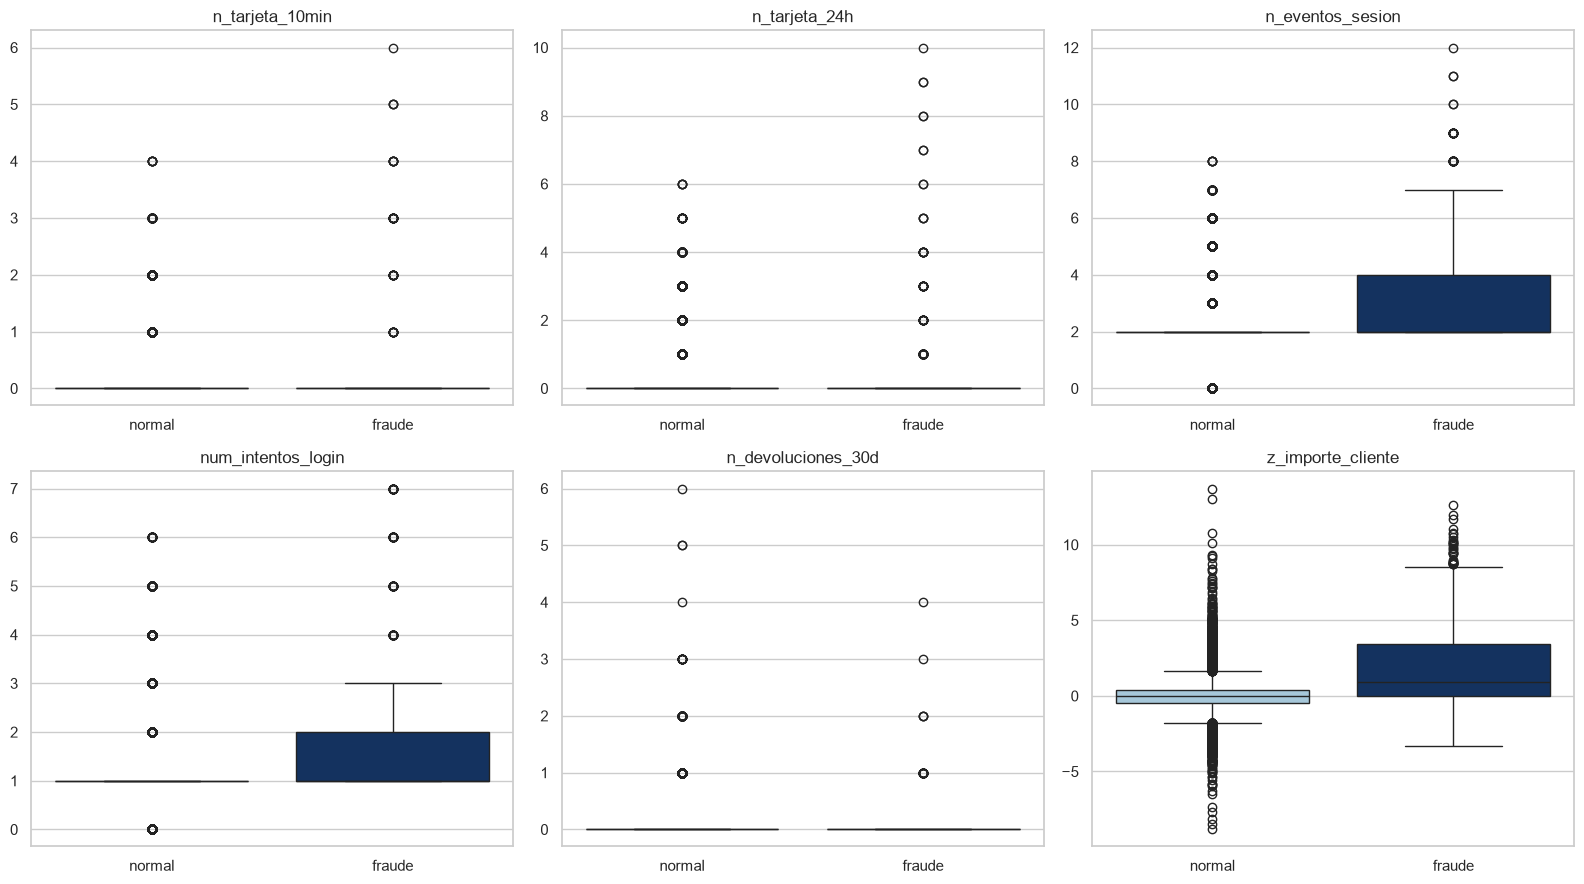

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,IQR n_tarjeta_10min,1384,3.5,46,3.3,6.6
1,IQR n_tarjeta_24h,6646,16.8,91,1.4,13.1
2,IQR n_eventos_sesion,15315,38.7,336,2.2,48.2
3,IQR num_intentos_login,12885,32.5,263,2.0,37.7
4,IQR n_devoluciones_30d,1998,5.0,36,1.8,5.2
5,IQR z_importe_cliente,3329,8.4,307,9.2,44.0


In [7]:
VARIABLES = ["n_tarjeta_10min", "n_tarjeta_24h", "n_eventos_sesion", "num_intentos_login",
             "n_devoluciones_30d", "z_importe_cliente"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, var in zip(axes.flat, VARIABLES):
    sns.boxplot(data=df, x="clase", y=var, hue="clase", order=["normal", "fraude"],
                palette=CLASES, legend=False, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

iqr_otras = pd.DataFrame([evaluar(fuera_iqr(df[v]), f"IQR {v}") for v in VARIABLES])
iqr_otras.round(1)

Variables de conteo: casi todos los valores son 0, 1 o 2, así que cualquier valor distinto sale como outlier. El IQR de n_eventos_sesion marca el 38,7 % de las transacciones y el de num_intentos_login, el 32,5 %.

Aun así aportan información: n_eventos_sesion captura el 48,2 % del fraude y num_intentos_login el 37,7 %. El comportamiento en la sesión complementa a las señales basadas solo en el importe, pero con una precisión del 2 % no sirven como regla por sí solas.


**Conclusiones de los outliers univariantes**

- Ningún método univariante basta. El más equilibrado (IQR sobre el logaritmo) detecta el 50,8 % del fraude con un 40,6 % de precisión: o se detecta poco, o hay muchas falsas alarmas.
- El IQR es más robusto que el Z-score porque no asume normalidad, pero sobre el importe tal cual marca el 7,7 % de todas las transacciones.
- El IQR no sirve para variables de conteo: cualquier valor distinto del habitual sale como outlier.
- Los outliers no se eliminan: en detección de fraude son justo los casos que interesan.


## 2. Patrones simples de fraude

A diferencia de los outliers, aquí cada transacción no se compara con todas las demás, sino con su propio contexto: el historial de ese cliente y lo que ha pasado con esa tarjeta o en esa sesión en los minutos anteriores.

**Índice**
1. Pico de gasto
2. Ráfagas
3. Velocidad dentro de la sesión
4. Comparativa de patrones
5. Qué tipo de fraude detecta cada patrón
6. Combinación de patrones

### 2.1. Pico de gasto respecto al cliente

z_importe_cliente mide cuánto se aleja el importe del gasto habitual de ese cliente, usando solo sus compras anteriores. Un pago de 300 € no es raro en el conjunto, pero sí para alguien que siempre gasta 20 €.

In [8]:
def comparar_umbrales(col, umbrales, etiqueta):
    return pd.DataFrame([evaluar(df[col] >= u, f"{etiqueta} >= {u}") for u in umbrales])

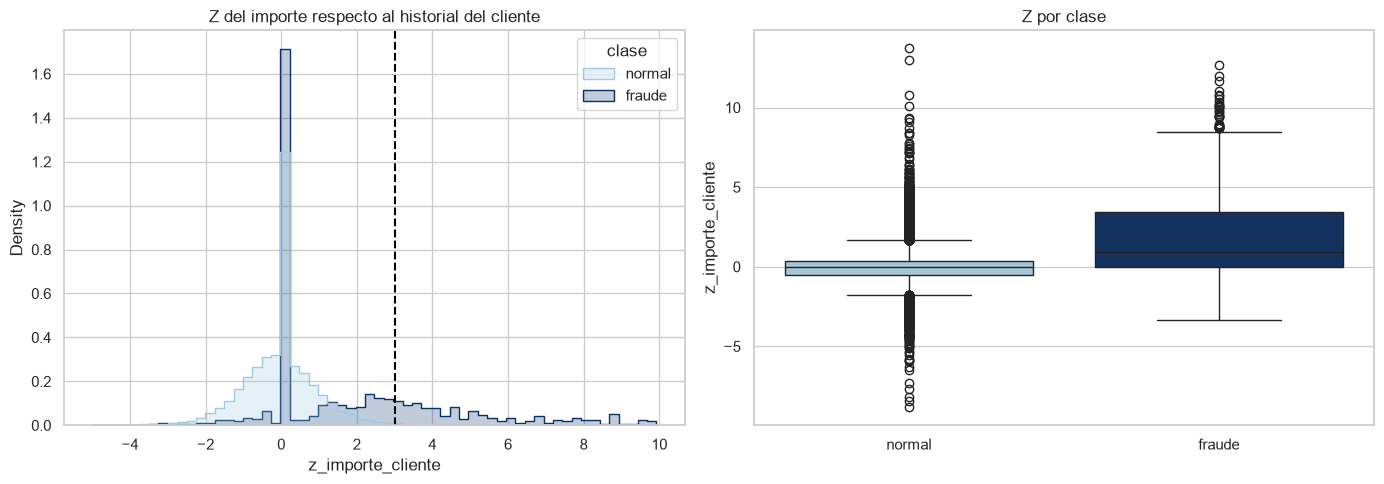

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df[df["z_importe_cliente"].between(-5, 10)], x="z_importe_cliente", hue="clase",
             palette=CLASES, bins=60, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].axvline(3, color="black", linestyle="--")
axes[0].set_title("Z del importe respecto al historial del cliente")
sns.boxplot(data=df, x="clase", y="z_importe_cliente", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[1])
axes[1].set_title("Z por clase")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

In [10]:
comparar_umbrales("z_importe_cliente", [2, 3, 4, 5], "z cliente").round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,z cliente >= 2,1365,3.4,283,20.7,40.6
1,z cliente >= 3,557,1.4,205,36.8,29.4
2,z cliente >= 4,280,0.7,136,48.6,19.5
3,z cliente >= 5,160,0.4,99,61.9,14.2


### 2.2. Ráfagas con la misma tarjeta

Cuántos pagos se han hecho con la misma tarjeta en los 10 minutos y en las 24 horas anteriores. Una persona rara vez paga cinco veces seguidas con la misma tarjeta; un bot probando si funciona, sí.

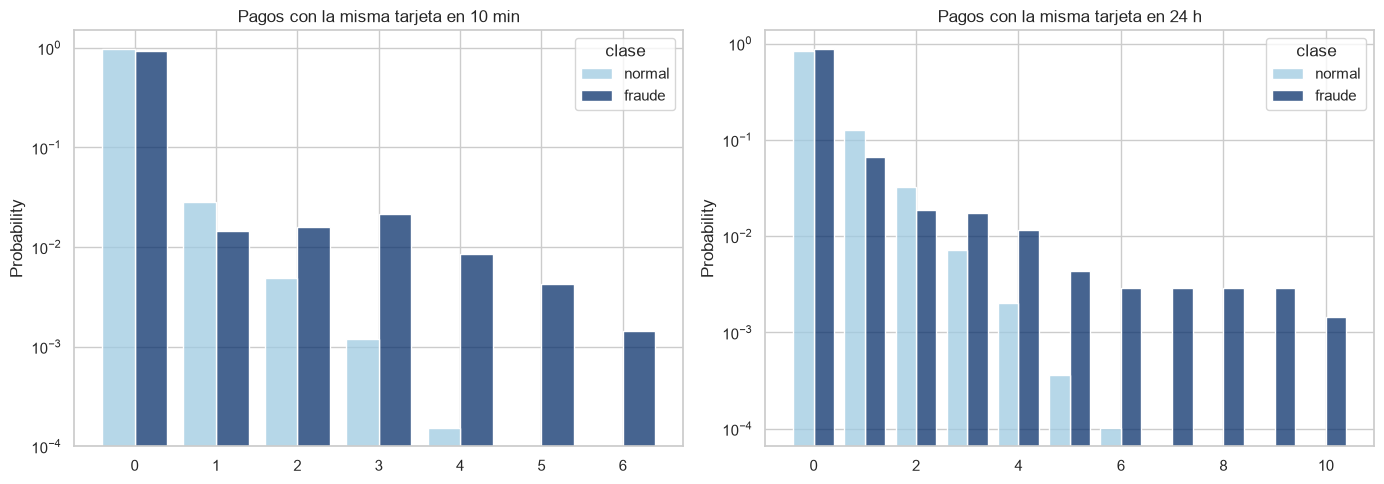

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, titulo in zip(axes, ["n_tarjeta_10min", "n_tarjeta_24h"],
                           ["Pagos con la misma tarjeta en 10 min", "Pagos con la misma tarjeta en 24 h"]):
    sns.histplot(data=df[df[col] <= 15], x=col, hue="clase", palette=CLASES, discrete=True,
                 stat="probability", common_norm=False, multiple="dodge", shrink=0.8, ax=ax)
    ax.set_yscale("log")   # sin escala log, la barra del valor 1 aplasta el resto
    ax.set_title(titulo)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [12]:
pd.concat([comparar_umbrales("n_tarjeta_10min", [3, 5], "10 min"),
           comparar_umbrales("n_tarjeta_24h", [5, 10], "24 h")]).round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,10 min >= 3,77,0.2,25,32.5,3.6
1,10 min >= 5,4,0.0,4,100.0,0.6
0,24 h >= 5,30,0.1,12,40.0,1.7
1,24 h >= 10,1,0.0,1,100.0,0.1


### 2.3. Velocidad dentro de la sesión

Número de eventos de la sesión e intentos de login. Muchos eventos seguidos apuntan a un bot; muchos intentos de login, a alguien probando contraseñas. Los pagos presenciales (datáfono) no tienen sesión, así que salen con valor 0.

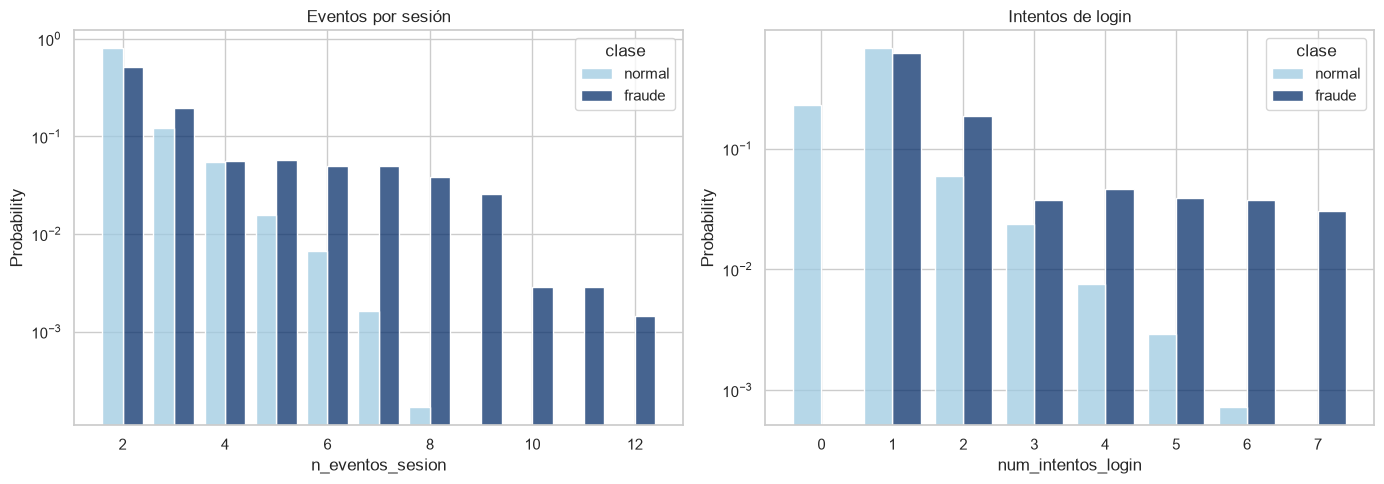

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df[df["n_eventos_sesion"].between(1, 15)], x="n_eventos_sesion", hue="clase",
             palette=CLASES, discrete=True, stat="probability", common_norm=False,
             multiple="dodge", shrink=0.8, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Eventos por sesión")
sns.histplot(data=df[df["num_intentos_login"] <= 8], x="num_intentos_login", hue="clase",
             palette=CLASES, discrete=True, stat="probability", common_norm=False,
             multiple="dodge", shrink=0.8, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Intentos de login")
plt.tight_layout()
plt.show()

In [14]:
pd.concat([comparar_umbrales("n_eventos_sesion", [5, 8, 12], "eventos sesión"),
           comparar_umbrales("num_intentos_login", [2, 3, 4], "intentos login"),
           comparar_umbrales("n_devoluciones_30d", [1], "devoluciones")]).round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,eventos sesión >= 5,885,2.2,160,18.1,23.0
1,eventos sesión >= 8,55,0.1,50,90.9,7.2
2,eventos sesión >= 12,1,0.0,1,100.0,0.1
0,intentos login >= 2,3905,9.9,263,6.7,37.7
1,intentos login >= 3,1485,3.7,132,8.9,18.9
2,intentos login >= 4,544,1.4,106,19.5,15.2
0,devoluciones >= 1,1998,5.0,36,1.8,5.2


### 2.4. Comparativa de patrones

Se fija un umbral para cada patrón, eligiendo el que mejor equilibra precisión y recall en las tablas anteriores.

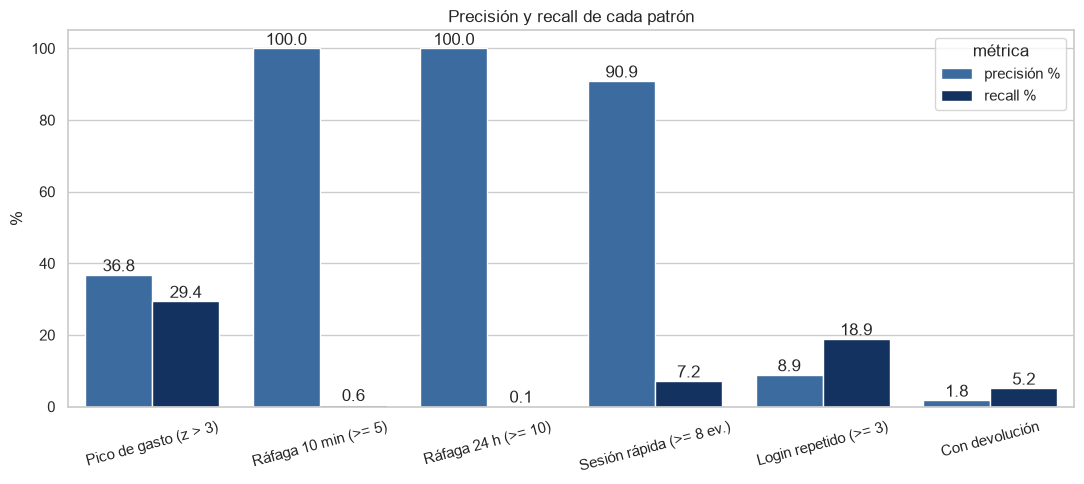

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,Pico de gasto (z > 3),557,1.4,205,36.8,29.4
1,Ráfaga 10 min (>= 5),4,0.0,4,100.0,0.6
2,Ráfaga 24 h (>= 10),1,0.0,1,100.0,0.1
3,Sesión rápida (>= 8 ev.),55,0.1,50,90.9,7.2
4,Login repetido (>= 3),1485,3.7,132,8.9,18.9
5,Con devolución,1998,5.0,36,1.8,5.2


In [15]:
REGLAS = {
    "Pico de gasto (z > 3)": df["z_importe_cliente"] > 3,
    "Ráfaga 10 min (>= 5)": df["n_tarjeta_10min"] >= 5,
    "Ráfaga 24 h (>= 10)": df["n_tarjeta_24h"] >= 10,
    "Sesión rápida (>= 8 ev.)": df["n_eventos_sesion"] >= 8,
    "Login repetido (>= 3)": df["num_intentos_login"] >= 3,
    "Con devolución": df["n_devoluciones_30d"] >= 1,
}
comparativa = pd.DataFrame([evaluar(m, n) for n, m in REGLAS.items()])

fig, ax = plt.subplots(figsize=(11, 5))
larga = comparativa.melt(id_vars="método", value_vars=["precisión %", "recall %"],
                         var_name="métrica", value_name="valor")
sns.barplot(data=larga, x="método", y="valor", hue="métrica", palette=[AZUL, "#08306b"], ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("Precisión y recall de cada patrón")
ax.set_xlabel("")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

comparativa.round(1)

### 2.5. Qué tipo de fraude detecta cada patrón

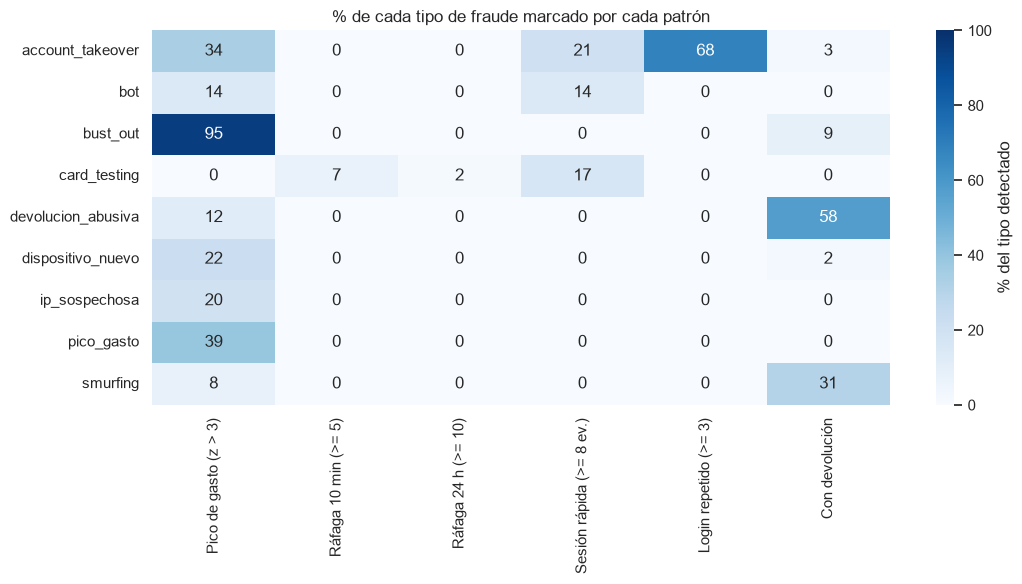

In [16]:
fraude = df[df["es_fraude"] == 1]
por_tipo = pd.DataFrame({n: m[fraude.index].groupby(fraude["tipo_fraude"]).mean() * 100
                         for n, m in REGLAS.items()}).astype(float)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(por_tipo, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "% del tipo detectado"}, ax=ax)
ax.set_title("% de cada tipo de fraude marcado por cada patrón")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Técnicas estadísticas para detección de anomalías

Los patrones anteriores miraban una señal cada vez. Aquí se combinan todas en un único **score de anomalía**: un número por transacción que indica cómo de rara es en conjunto. Se comparan tres formas de construirlo, todas estadísticas (sin machine learning todavía).

**Índice**
1. Variables que entran en el score
2. Correlación entre variables
3. Score por suma de señales
4. Score por percentiles
5. Distancia de Mahalanobis
6. Comparativa de los tres scores
7. Umbral elegido
8. Qué se sigue escapando

### 3.1. Variables que entran en el score

Las mismas señales de los apartados anteriores, ahora como variables numéricas en vez de reglas de sí/no.

In [17]:
VARIABLES = ["z_importe_cliente", "n_tarjeta_10min", "n_tarjeta_24h",
             "n_eventos_sesion", "num_intentos_login", "n_devoluciones_30d"]
X = df[VARIABLES].astype(float)   
X.describe().round(2)

,z_importe_cliente,n_tarjeta_10min,n_tarjeta_24h,n_eventos_sesion,num_intentos_login,n_devoluciones_30d
count,39603.00,39603.00,39603.00,39603.00,39603.00,39603.00
mean,0.01,0.04,0.22,1.81,0.93,0.05
std,1.09,0.26,0.58,1.21,0.75,0.24
min,-8.83,0.00,0.00,0.00,0.00,0.00
25%,-0.49,0.00,0.00,2.00,1.00,0.00
50%,0.00,0.00,0.00,2.00,1.00,0.00
75%,0.39,0.00,0.00,2.00,1.00,0.00
max,13.72,6.00,10.00,12.00,7.00,6.00


### 3.2. Correlación entre variables

Si dos variables están muy correlacionadas miden casi lo mismo, y al sumarlas en un score ese aspecto cuenta doble.

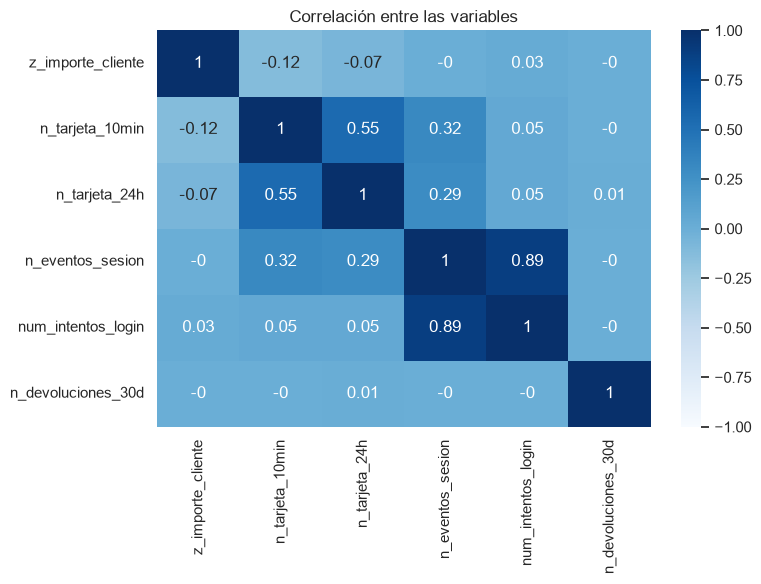

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(X.corr().round(2), annot=True, cmap="Blues", vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title("Correlación entre las variables")
plt.tight_layout()
plt.show()

### 3.3. Score por suma de señales

El más simple: cada señal aporta 1 punto si se activa, así que el score va de 0 a 4.

La ráfaga usa aquí un umbral más bajo (≥ 3 pagos en 10 min) que en la comparativa de patrones (≥ 5). Como regla aislada, ≥ 3 da demasiadas falsas alarmas. Como una señal más de un score, basta con que sume un punto.


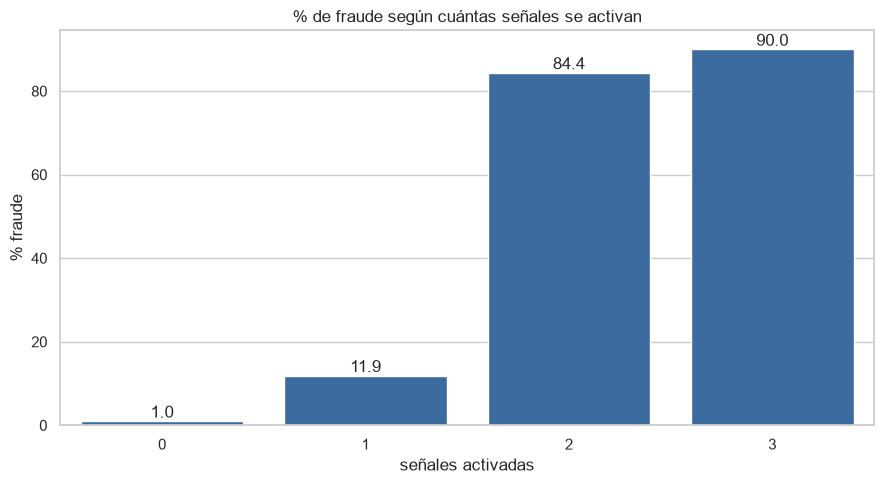

,score_señales,transacciones,fraudes,% fraude
0,0,37539,379,1.0
1,1,1964,233,11.9
2,2,90,76,84.4
3,3,10,9,90.0


In [19]:
SENALES = {
    "importe anómalo": X["z_importe_cliente"] > 3,
    "ráfaga tarjeta": X["n_tarjeta_10min"] >= 3,
    "sesión rápida": X["n_eventos_sesion"] >= 8,
    "login repetido": X["num_intentos_login"] >= 3,
}
df["score_señales"] = sum(s.astype(int) for s in SENALES.values())

resumen = (df.groupby("score_señales")
             .agg(transacciones=("es_fraude", "size"), fraudes=("es_fraude", "sum"))
             .reset_index())
resumen["% fraude"] = (resumen["fraudes"] / resumen["transacciones"] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=resumen, x="score_señales", y="% fraude", color=AZUL, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("% de fraude según cuántas señales se activan")
ax.set_xlabel("señales activadas")
plt.tight_layout()
plt.show()

resumen

### 3.4. Score por percentiles

Cada variable se convierte a su percentil (de 0 a 1), lo que las pone a todas en la misma escala aunque una vaya en euros y otra en número de eventos. El score es el percentil más alto de sus variables: basta con destacar en una para ser sospechosa.

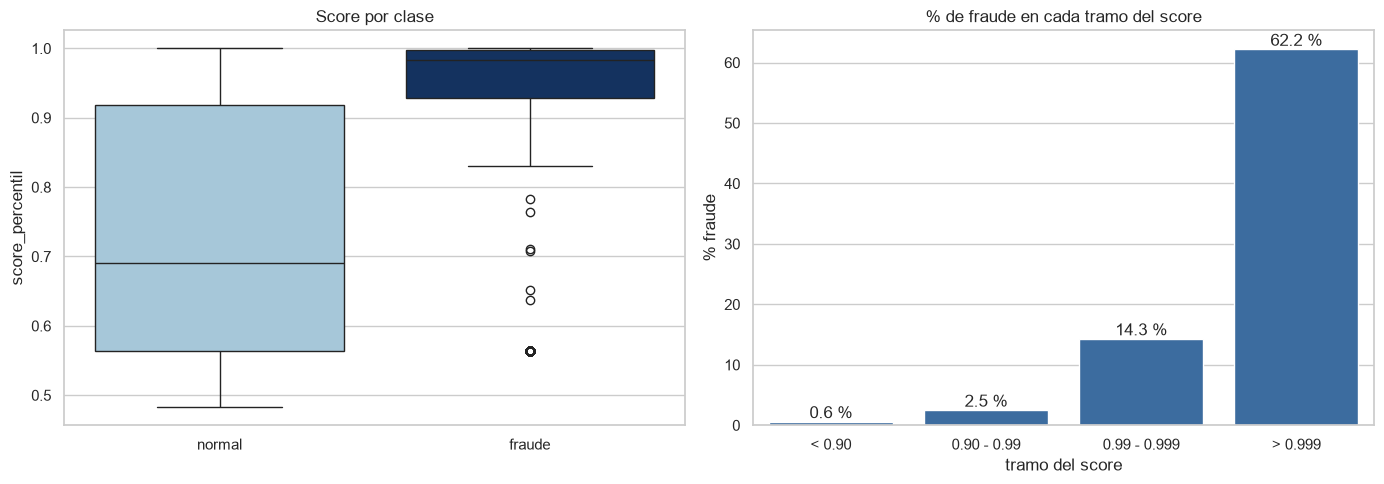

,score_percentil,transacciones,fraudes,% fraude
0,< 0.90,28757,167,0.6
1,0.90 - 0.99,9269,236,2.5
2,0.99 - 0.999,1434,205,14.3
3,> 0.999,143,89,62.2


In [20]:
percentiles = X.rank(pct=True)
df["score_percentil"] = percentiles.max(axis=1)

# Tramos del score: el 90 % más bajo, y luego los tres escalones superiores
tramos = pd.cut(df["score_percentil"], [0, 0.9, 0.99, 0.999, 1.0],
                labels=["< 0.90", "0.90 - 0.99", "0.99 - 0.999", "> 0.999"])
por_tramo = (df.groupby(tramos, observed=True)
               .agg(transacciones=("es_fraude", "size"), fraudes=("es_fraude", "sum"))
               .reset_index())
por_tramo["% fraude"] = (por_tramo["fraudes"] / por_tramo["transacciones"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="clase", y="score_percentil", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[0])
axes[0].set_title("Score por clase")
axes[0].set_xlabel("")

sns.barplot(data=por_tramo, x="score_percentil", y="% fraude", color=AZUL, ax=axes[1])
for cont in axes[1].containers:
    axes[1].bar_label(cont, fmt="%.1f %%")
axes[1].set_title("% de fraude en cada tramo del score")
axes[1].set_xlabel("tramo del score")
plt.tight_layout()
plt.show()

por_tramo

In [21]:
pd.DataFrame([evaluar(df["score_percentil"] >= u, f"percentil >= {u}")
              for u in [0.95, 0.99, 0.995, 0.999]]).round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,percentil >= 0.95,7334,18.5,447,6.1,64.1
1,percentil >= 0.99,1577,4.0,294,18.6,42.2
2,percentil >= 0.995,842,2.1,223,26.5,32.0
3,percentil >= 0.999,143,0.4,89,62.2,12.8


### 3.5. Distancia de Mahalanobis

La técnica multivariante clásica. Mide a qué distancia está cada transacción del "centro" de los datos, teniendo en cuenta que las variables están correlacionadas: dos valores altos a la vez cuentan menos si esas dos variables suelen subir juntas.

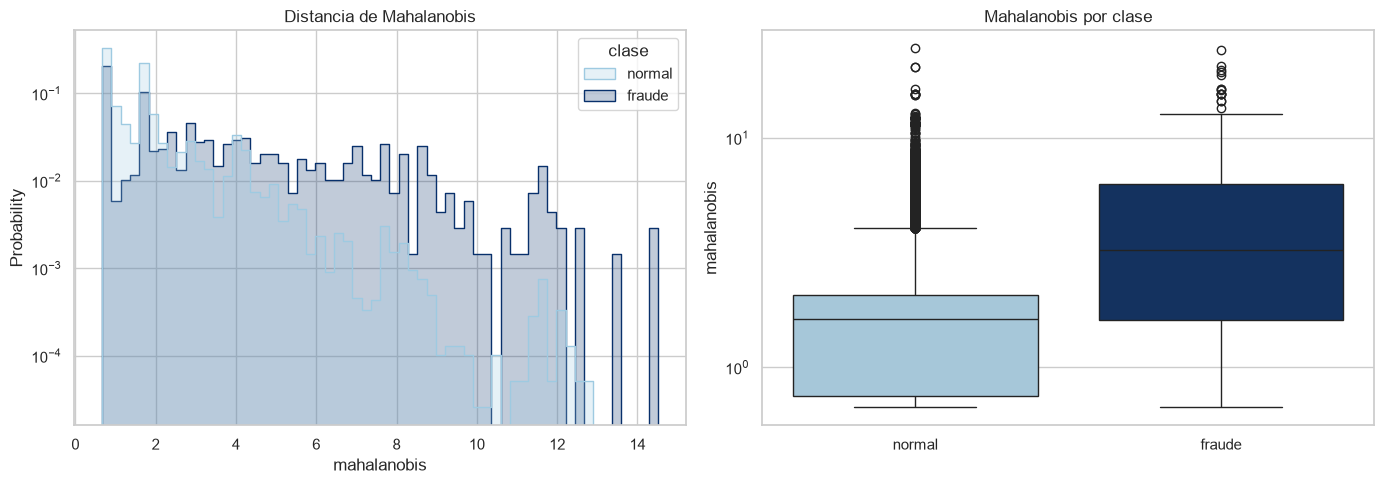

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,mahalanobis >= 3,6536,16.5,370,5.7,53.1
1,mahalanobis >= 5,1679,4.2,227,13.5,32.6
2,mahalanobis >= 8,390,1.0,100,25.6,14.3
3,mahalanobis >= 12,51,0.1,19,37.3,2.7


In [22]:
media = X.mean()
cov_inv = np.linalg.pinv(X.cov().values)   # pinv: tolera variables muy correlacionadas
centrada = (X - media).values
df["mahalanobis"] = np.sqrt(np.einsum("ij,jk,ik->i", centrada, cov_inv, centrada))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df[df["mahalanobis"] < 15], x="mahalanobis", hue="clase", palette=CLASES,
             bins=60, stat="probability", common_norm=False, element="step", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Distancia de Mahalanobis")
sns.boxplot(data=df, x="clase", y="mahalanobis", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Mahalanobis por clase")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

pd.DataFrame([evaluar(df["mahalanobis"] >= u, f"mahalanobis >= {u}")
              for u in [3, 5, 8, 12]]).round(1)

## 6. Comparativa de los tres scores

Cada punto es un umbral distinto. Cuanto más arriba y a la derecha esté la curva, mejor es el score. La línea gris es la precisión que se obtendría marcando transacciones al azar.

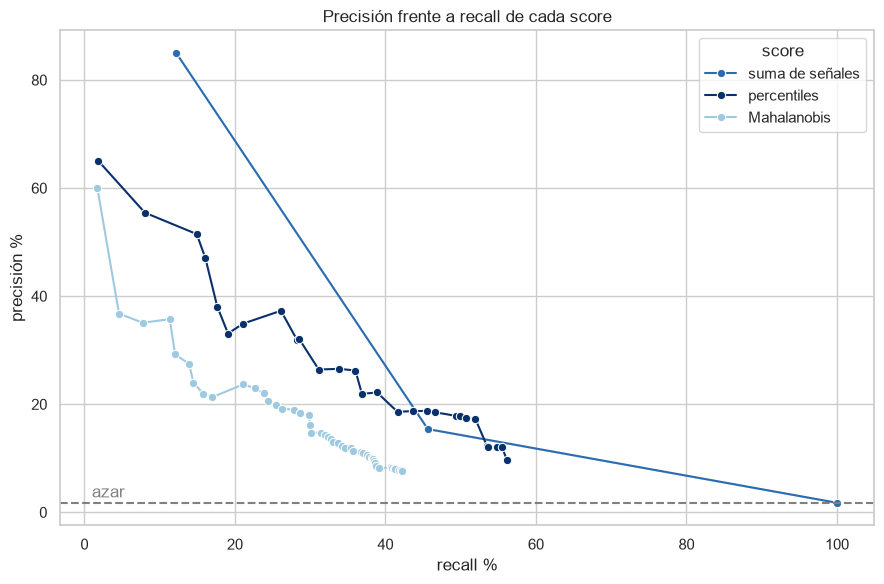

In [23]:
def curva(score, nombre, pasos=60):
    filas = []
    for q in np.linspace(0.90, 0.9995, pasos):
        marcadas = score >= score.quantile(q)
        n = int(marcadas.sum())
        vp = int((marcadas & (df["es_fraude"] == 1)).sum())
        if n:
            filas.append({"score": nombre, "precisión %": vp / n * 100,
                          "recall %": vp / TOTAL_FRAUDE * 100})
    return pd.DataFrame(filas)

curvas = pd.concat([curva(df["score_señales"], "suma de señales"),
                    curva(df["score_percentil"], "percentiles"),
                    curva(df["mahalanobis"], "Mahalanobis")])

fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(data=curvas, x="recall %", y="precisión %", hue="score", marker="o",
             palette=[AZUL, "#08306b", "#9ecae1"], ax=ax)
ax.axhline(df["es_fraude"].mean() * 100, color="grey", linestyle="--")
ax.text(1, df["es_fraude"].mean() * 100 + 1, "azar", color="grey")
ax.set_title("Precisión frente a recall de cada score")
plt.tight_layout()
plt.show()

### 3.7. Umbral elegido

Se marca como sospechoso el 1 % de transacciones con el score más alto.

In [24]:
UMBRAL = df["score_percentil"].quantile(0.99)
df["sospechosa"] = df["score_percentil"] >= UMBRAL
print(f"Umbral (percentil 99 del score): {UMBRAL:.4f}")

display(pd.DataFrame([evaluar(df["sospechosa"], "score percentil p99")]).round(1))

pd.crosstab(df["es_fraude"].map({0: "real: normal", 1: "real: fraude"}),
            df["sospechosa"].map({False: "pred: normal", True: "pred: sospechosa"}))

Umbral (percentil 99 del score): 0.9982


,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,score percentil p99,402,1.0,133,33.1,19.1


sospechosa,pred: normal,pred: sospechosa
es_fraude,,
real: fraude,564,133
real: normal,38637,269


### 3.8. Qué se sigue escapando

Porcentaje de cada tipo de fraude que marca el umbral elegido. Los tipos con recall bajo son los que el hito 3 tiene que mejorar.

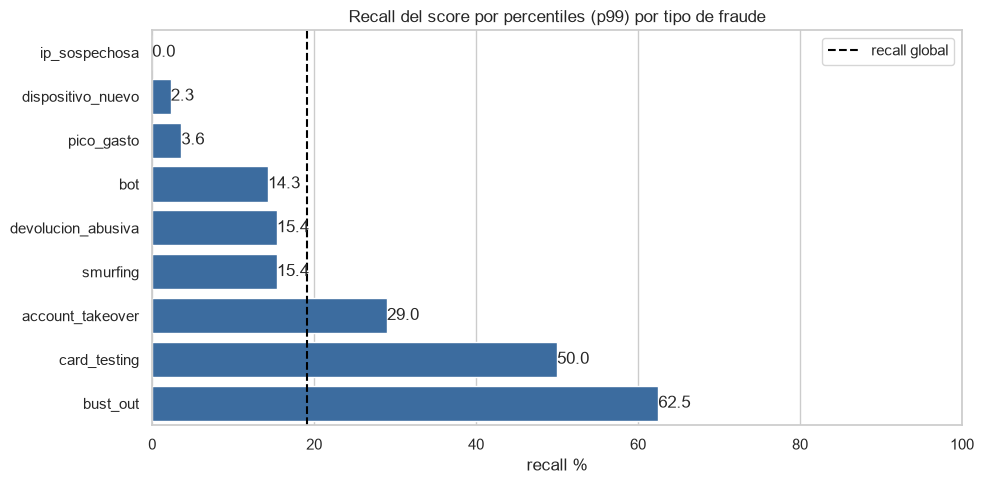

,fraudes,detectados,recall %
tipo_fraude,,,
ip_sospechosa,20,0,0.0
dispositivo_nuevo,300,7,2.3
pico_gasto,28,1,3.6
bot,7,1,14.3
devolucion_abusiva,26,4,15.4
smurfing,13,2,15.4
account_takeover,193,56,29.0
card_testing,54,27,50.0
bust_out,56,35,62.5


In [25]:
recall_tipo = (df[df["es_fraude"] == 1]
               .groupby("tipo_fraude")
               .agg(fraudes=("sospechosa", "size"), detectados=("sospechosa", "sum")))
recall_tipo["recall %"] = (recall_tipo["detectados"] / recall_tipo["fraudes"] * 100).round(1)
recall_tipo = recall_tipo.sort_values("recall %")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=recall_tipo.reset_index(), y="tipo_fraude", x="recall %", color=AZUL, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.axvline(recall_tipo["detectados"].sum() / recall_tipo["fraudes"].sum() * 100,
           color="black", linestyle="--", label="recall global")
ax.set_title("Recall del score por percentiles (p99) por tipo de fraude")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

recall_tipo


Combinar señales mejora a cualquier regla aislada, pero con el 1 % marcado se escapa más del 80 % del fraude. Esta es la referencia que tienen que superar los modelos del hito 3, medidos con el mismo criterio: precisión y recall al marcar el 1 % de transacciones.

## 4. Carga de trabajo para los analistas

Cada transacción marcada como sospechosa acabará siendo una alerta que un analista tiene que revisar. Por eso el umbral no se elige solo por precisión y recall: también tiene que generar un volumen de alertas que el equipo pueda revisar al día.

Aquí solo se lee la tabla analista para saber cuántos hay activos. Los datos de analistas **no** entran en features_transaccion ni en el dataset de ML: el veredicto de un analista se conoce después del pago y depende de si era fraude, así que como variable sería fuga de información.


Analistas activos: 6   Días de datos: 180   Alertas en la tabla alerta: 0 (se rellenará a partir del hito 3)



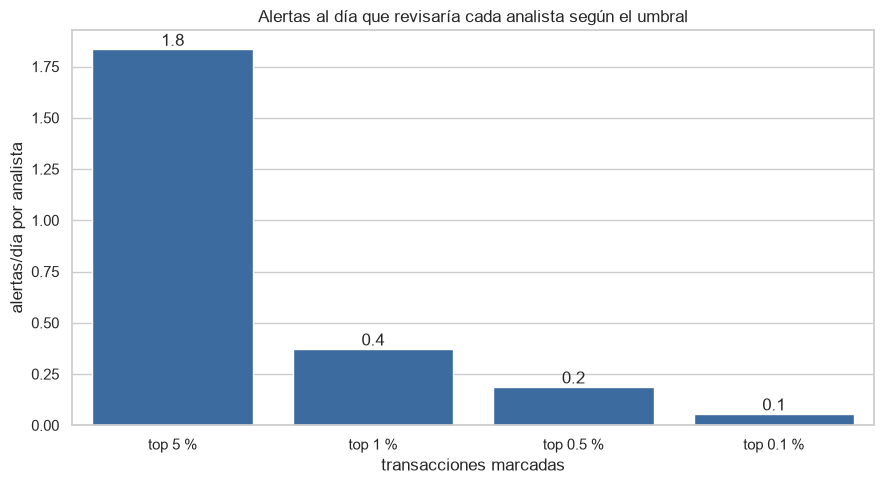

,método,marcadas,alertas/día,alertas/día por analista,precisión %,recall %
0,top 5 %,1981,11.0,1.8,17.7,50.2
1,top 1 %,402,2.2,0.4,33.1,19.1
2,top 0.5 %,202,1.1,0.2,51.5,14.9
3,top 0.1 %,60,0.3,0.1,71.7,6.2


In [26]:
n_analistas = client.command("SELECT count() FROM analista WHERE activo")
n_alertas = client.command("SELECT count() FROM alerta")
dias = (df["timestamp"].max() - df["timestamp"].min()).days + 1
print(f"Analistas activos: {n_analistas}   Días de datos: {dias}   "
      f"Alertas en la tabla alerta: {n_alertas} (se rellenará a partir del hito 3)\n")

filas = []
for q in [0.95, 0.99, 0.995, 0.999]:
    marcadas = df["score_percentil"] >= df["score_percentil"].quantile(q)
    r = evaluar(marcadas, f"top {(1 - q) * 100:g} %")
    r["alertas/día"] = r["marcadas"] / dias
    r["alertas/día por analista"] = r["alertas/día"] / n_analistas
    filas.append(r)
carga = pd.DataFrame(filas)[["método", "marcadas", "alertas/día", "alertas/día por analista",
                             "precisión %", "recall %"]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=carga, x="método", y="alertas/día por analista", color=AZUL, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("Alertas al día que revisaría cada analista según el umbral")
ax.set_xlabel("transacciones marcadas")
plt.tight_layout()
plt.show()

carga.round(1)


Bajar el umbral sube el recall, pero multiplica las alertas: hay que fijar cuántas puede revisar cada analista al día y elegir el umbral con mayor recall dentro de ese límite. A partir del hito 3, las transacciones marcadas se guardarán en alerta y la vista alertas_enriquecidas permitirá medir lo que aquí solo se estima: carga real, tiempo de revisión y concordancia del veredicto con es_fraude.